In [8]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

import re
%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [9]:
# Get csvs of results for each model 

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in model_paths:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
            csv = csv.as_posix()
            try:
                df = pd.read_csv(csv)
                #print(model)

                df['version'] = csv.split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[3]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[3]
                    
            #       print(test_parts)
            
                if 'dB_SNR' in csv:
                    df['snr_condition'] = re.search('(-?\d+)dB', csv).group(0)
                else:
                    df['snr_condition'] = 'clean'
                    
                    
                if len(df.filter(regex='acc_step').columns) != 0:
                    df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                    df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]
                    

                dfs.append(df)
            except Exception as e:
                print(e)
                bad_files.append((csv, e))

    #         if 'Test' in path.as_posix()
    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

In [10]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit/')


timit_models = list(parent_path.glob("*"))

In [11]:
# talker_results

In [12]:
timit_results, _ = get_df_from_dir(timit_models)



In [13]:
timit_results

,ACC/test_fg_acc,step,version,model,snr_condition,test_confusion
170,0.500,0,4,MultiDistractorAttnCNN,-10dB,0.000
171,0.125,1,4,MultiDistractorAttnCNN,-10dB,0.250
172,0.375,2,4,MultiDistractorAttnCNN,-10dB,0.125
173,0.250,3,4,MultiDistractorAttnCNN,-10dB,0.250
174,0.000,4,4,MultiDistractorAttnCNN,-10dB,0.500
...,...,...,...,...,...,...
2035,0.500,80,4,MultiDistractorAttnCNN,clean,0.000
2036,0.875,81,4,MultiDistractorAttnCNN,clean,0.000
2037,0.750,82,4,MultiDistractorAttnCNN,clean,0.000
2038,0.750,83,4,MultiDistractorAttnCNN,clean,0.000


## Compare models trained with single talker distractors to models trained with audioset distractors 



In [15]:
# Match names 
# snr_data_for_plot
# multi = snr_data_for_plot[snr_data_for_plot.model == 'talkers + audioset']

acc = list(timit_results.filter(regex="test_fg_acc"))

confs = list(timit_results.filter(regex="confusion"))


snr_acc_data = pd.melt(timit_results, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=acc,
                            var_name='batch_ix',
                            value_name='accuracy').dropna()

conf_data = pd.melt(timit_results, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=confs,
                            var_name='batch_ix',
                            value_name='confusions').dropna()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


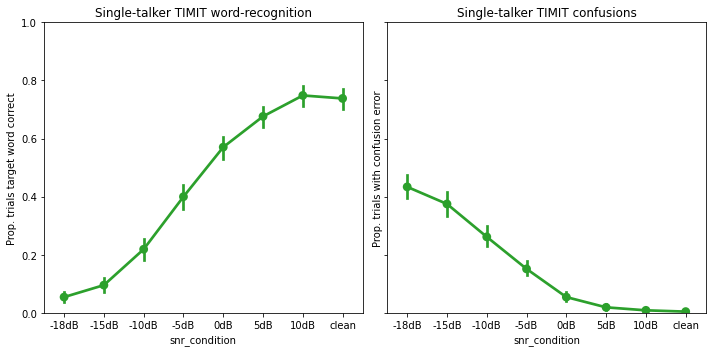

In [40]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,5))
axs = axs.ravel()
snr_order = ["-18dB", "-15dB", '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_acc_data, x='snr_condition', y='accuracy',
#     hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    color='tab:green', order=snr_order
)

g1 = sn.pointplot(
    data=conf_data, x='snr_condition', y='confusions',
#     hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[1],
    color='tab:green', order=snr_order
)


g.set_title("Single-talker TIMIT word-recognition")
g1.set_title("Single-talker TIMIT confusions")
axs[0].set_ylabel("Prop. trials target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")

g.legend().remove()
g1.legend().remove()
plt.ylim(0,1)
plt.tight_layout()
